In [1]:
import os
import json
import joblib
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

from improved_model import build_all_models, get_training_config


In [10]:
# =========================================================
# CONFIG
# =========================================================

BASE_DIR = os.getcwd()
if not os.path.exists(os.path.join(BASE_DIR, "dataset_word")):
    parent_dir = os.path.abspath(os.path.join(BASE_DIR, ".."))
    if os.path.exists(os.path.join(parent_dir, "dataset_word")):
        BASE_DIR = parent_dir

DATA_DIR = os.path.join(BASE_DIR, "dataset_word", "landmarks", "final")

MODEL_DIR = os.path.join(BASE_DIR, "models", "final")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", "final")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

LABEL_SMOOTHING = 0.1

In [3]:
# =========================================================
# AUGMENTATION
# =========================================================

def augment_sequence(seq):

    augmented = []

    # original
    augmented.append(seq)

    # gaussian noise
    noise = seq + np.random.normal(0, 0.01, seq.shape)
    augmented.append(noise)

    # temporal shift
    shift = np.roll(seq, np.random.randint(1, 5), axis=0)
    augmented.append(shift)

    # crop + pad
    crop_len = int(len(seq) * 0.8)

    start = (len(seq) - crop_len) // 2

    cropped = seq[start:start + crop_len]

    pad = np.repeat(
        cropped[-1:],
        len(seq) - crop_len,
        axis=0
    )

    cropped = np.vstack((cropped, pad))

    augmented.append(cropped)

    # feature dropout
    dropout_mask = np.random.binomial(
        1,
        0.9,
        seq.shape
    )

    dropped = seq * dropout_mask

    augmented.append(dropped)

    return augmented

In [4]:
# =========================================================
# MIXUP AUGMENTATION
# =========================================================

def mixup_data(X, y, alpha=0.2):

    indices = np.random.permutation(len(X))

    X2 = X[indices]
    y2 = y[indices]

    lam = np.random.beta(alpha, alpha)

    X_mix = lam * X + (1 - lam) * X2

    return X_mix, y, y2, lam


# =========================================================
# TEMPORAL CONSISTENCY LOSS
# =========================================================

class TemporalConsistencyLoss(tf.keras.losses.Loss):

    def __init__(self,
                 num_classes,
                 label_smoothing=0.1,
                 temporal_weight=0.05):

        super().__init__()

        self.num_classes = num_classes
        self.temporal_weight = temporal_weight

        self.ce = tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=label_smoothing
        )

    def call(self, y_true, y_pred):

        y_true = tf.one_hot(
            tf.cast(y_true, tf.int32),
            depth=self.num_classes
        )

        ce_loss = self.ce(y_true, y_pred)

        temporal_loss = tf.reduce_mean(
            tf.square(
                y_pred[1:] - y_pred[:-1]
            )
        )

        return ce_loss + (
            self.temporal_weight * temporal_loss
        )



In [11]:
# =========================================================
# LOAD DATA
# =========================================================

print("\n[1] Loading dataset...")

X = []
y = []


def normalize_sequence(seq, target_length, target_dim):

    seq = np.asarray(seq)

    if seq.ndim != 2:
        return None

    # Fix time dimension first
    if seq.shape[0] < target_length:
        pad_rows = np.zeros((target_length - seq.shape[0], seq.shape[1]), dtype=seq.dtype)
        seq = np.vstack([seq, pad_rows])
    elif seq.shape[0] > target_length:
        seq = seq[:target_length]

    # Then fix feature dimension
    if seq.shape[1] < target_dim:
        pad_cols = np.zeros((seq.shape[0], target_dim - seq.shape[1]), dtype=seq.dtype)
        seq = np.hstack([seq, pad_cols])
    elif seq.shape[1] > target_dim:
        seq = seq[:, :target_dim]

    return seq

classes = sorted(os.listdir(DATA_DIR))

raw_sequences = []

for cls in classes:

    path = os.path.join(DATA_DIR, cls)

    if not os.path.isdir(path):
        continue

    for file in os.listdir(path):

        if file.endswith(".npy"):

            seq = np.load(
                os.path.join(path, file)
            )

            raw_sequences.append(seq)
            y.append(cls)

if not raw_sequences:
    raise SystemExit(f"No .npy landmark sequences found in {DATA_DIR}")

target_length = max(seq.shape[0] for seq in raw_sequences if seq.ndim == 2)
target_dim = max(seq.shape[1] for seq in raw_sequences if seq.ndim == 2)

for seq in raw_sequences:
    normalized = normalize_sequence(seq, target_length, target_dim)
    if normalized is not None:
        X.append(normalized)

X = np.stack(X)
y = np.array(y)

print(f"Loaded {len(X)} sequences with shape {X.shape[1:]}")

print(f"Original samples: {len(X)}")
print(f"Total classes: {len(classes)}")


[1] Loading dataset...
Loaded 276 sequences with shape (40, 360)
Original samples: 276
Total classes: 22


In [13]:
# =========================================================
# LABEL ENCODING
# =========================================================

le = LabelEncoder()

y_encoded = le.fit_transform(y)

joblib.dump(
    le,
    os.path.join(MODEL_DIR, "label_encoder.pkl")
)


['d:\\Islington college\\masters\\nsl-landmark-thesis\\models\\final\\label_encoder.pkl']

In [14]:

# =========================================================
# TRAIN / VAL / TEST SPLIT
# =========================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

print("\nDataset Split:")
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))



Dataset Split:
Train: 176
Validation: 44
Test: 56


In [15]:
# =========================================================
# AUGMENT TRAIN ONLY
# =========================================================

print("\n[2] Applying augmentation...")

X_train_aug = []
y_train_aug = []

for seq, label in zip(X_train, y_train):

    augmented = augment_sequence(seq)

    for a in augmented:

        X_train_aug.append(a)
        y_train_aug.append(label)

X_train = np.array(X_train_aug)
y_train = np.array(y_train_aug)

print(f"Augmented train samples: {len(X_train)}")

# =========================================================
# AFTER AUGMENTATION REPORT
# =========================================================

print("\n==================================================")
print("AFTER AUGMENTATION REPORT")
print("==================================================")

print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

print("\nClass Distribution (TRAIN):")

unique_classes, counts = np.unique(
    y_train,
    return_counts=True
)

for cls, count in zip(unique_classes, counts):

    class_name = le.inverse_transform([cls])[0]

    print(f"{class_name}: {count}")



[2] Applying augmentation...
Augmented train samples: 880

AFTER AUGMENTATION REPORT
Train samples: 880
Validation samples: 44
Test samples: 56

Class Distribution (TRAIN):
aapatkal: 40
adhikari: 75
aspatal: 40
chori: 40
doctor: 40
durghatana: 35
hatya: 40
hinsa: 40
jach: 35
jhagada: 40
madat: 35
naam: 35
nagarikta: 40
parkhanuhos: 35
prahari: 40
roknuhos: 35
sahayata: 40
samasya: 40
thana: 40
thegana: 40
ujuri: 40
umer: 35


In [20]:
# =========================================================
# CLASS WEIGHTS
# =========================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(
    enumerate(class_weights)
)

# =========================================================
# MODEL SETUP
# =========================================================

config = get_training_config(len(classes))

input_shape = (
    X.shape[1],
    X.shape[2]
)

models_dict = build_all_models(
    input_shape,
    len(classes)
)

results = {}

    

In [21]:

# =========================================================
# TRAINING LOOP
# =========================================================

for model_name, model_fn in models_dict.items():

    print("\n" + "="*70)
    print(f"TRAINING MODEL: {model_name}")
    print("="*70)

    model = model_fn

    # cosine learning rate
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=config["learning_rate"],
        decay_steps=1000
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr_schedule,
        clipnorm=1.0
    )

    loss_fn = TemporalConsistencyLoss(
        num_classes=len(classes),
        label_smoothing=LABEL_SMOOTHING,
        temporal_weight=0.05
    )

    model.compile(
        optimizer=optimizer,
        loss=loss_fn,
        metrics=["accuracy"]
    )

    callbacks = [

        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),

        # Removed ReduceLROnPlateau because optimizer uses a LearningRateSchedule
        # (CosineDecay). ReduceLROnPlateau attempts to set optimizer.learning_rate
        # which is not allowed when a schedule object was provided.

        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(
                MODEL_DIR,
                f"{model_name}_best.h5"
            ),
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1
        )
    ]

    # =====================================================
    # MIXUP
    # =====================================================

    X_mix, y_a, y_b, lam = mixup_data(
        X_train,
        y_train
    )

    history = model.fit(
        X_mix,
        y_a,
        validation_data=(X_val, y_val),
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    # =====================================================
    # VALIDATION
    # =====================================================

    val_pred = np.argmax(
        model.predict(X_val),
        axis=1
    )

    val_acc = accuracy_score(
        y_val,
        val_pred
    )

    results[model_name] = val_acc

    print(f"\nValidation Accuracy: {val_acc:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    report = classification_report(
        y_val,
        val_pred,
        target_names=le.classes_
    )

    print(report)

    with open(
        os.path.join(
            OUTPUT_DIR,
            f"{model_name}_report.txt"
        ),
        "w"
    ) as f:

        f.write(report)

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(
        y_val,
        val_pred
    )

    plt.figure(figsize=(12, 10))

    sns.heatmap(
        cm,
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"{model_name}_cm.png"
        )
    )

    plt.close()

# =========================================================
# BEST MODEL
# =========================================================

best_model_name = max(
    results,
    key=results.get
)

print("\n🏆 BEST MODEL:", best_model_name)


TRAINING MODEL: GRU
Epoch 1/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0550 - loss: 3.1336
Epoch 1: val_accuracy improved from None to 0.02273, saving model to d:\Islington college\masters\nsl-landmark-thesis\models\final\GRU_best.h5



Epoch 1: finished saving model to d:\Islington college\masters\nsl-landmark-thesis\models\final\GRU_best.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.0580 - loss: 3.1067 - val_accuracy: 0.0227 - val_loss: 3.0703
Epoch 2/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0836 - loss: 3.0539
Epoch 2: val_accuracy improved from 0.02273 to 0.13636, saving model to d:\Islington college\masters\nsl-landmark-thesis\models\final\GRU_best.h5



Epoch 2: finished saving model to d:\Islington college\masters\nsl-landmark-thesis\models\final\GRU_best.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.0852 - loss: 3.0492 - val_accuracy: 0.1364 - val_loss: 3.0257
Epoch 3/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1377 - loss: 2.9968
Epoch 3: val_accuracy did not improve from 0.13636
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.1295 - loss: 2.9684 - val_accuracy: 0.0682 - val_loss: 3.0092
Epoch 4/120
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1357 - loss: 2.9426
Epoch 4: val_accuracy did not improve from 0.13636
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1341 - loss: 2.8956 - val_accuracy: 0.0682 - val_loss: 2.9201
Epoch 5/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1986 - loss: 2.7751
Epoch 5: val_accuracy did not improve from 0.13636
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2068 - loss: 2.7433 - val_accuracy: 0.0909 - val_loss: 2.8106
Epoch 6/120
55/5


Epoch 7: finished saving model to d:\Islington college\masters\nsl-landmark-thesis\models\final\GRU_best.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.2625 - loss: 2.5181 - val_accuracy: 0.1818 - val_loss: 2.5482
Epoch 8/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2390 - loss: 2.4864
Epoch 8: val_accuracy did not improve from 0.18182
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2659 - loss: 2.4547 - val_accuracy: 0.1591 - val_loss: 2.5610
Epoch 9/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2620 - loss: 2.3781
Epoch 9: val_accuracy improved from 0.18182 to 0.20455, saving model to d:\Islington college\masters\nsl-landmark-thesis\models\final\GRU_best.h5



Epoch 9: finished saving model to d:\Islington college\masters\nsl-landmark-thesis\models\final\GRU_best.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.2636 - loss: 2.3697 - val_accuracy: 0.2045 - val_loss: 2.5102
Epoch 10/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3043 - loss: 2.3009
Epoch 10: val_accuracy improved from 0.20455 to 0.27273, saving model to d:\Islington college\masters\nsl-landmark-thesis\models\final\GRU_best.h5


...


Epoch 5: finished saving model to d:\Islington college\masters\nsl-landmark-thesis\models\final\BiGRU_Attention_best.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.5511 - loss: 1.7929 - val_accuracy: 0.6136 - val_loss: 1.6917
Epoch 6/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5681 - loss: 1.6887
Epoch 6: val_accuracy did not improve from 0.61364
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.5932 - loss: 1.6460 - val_accuracy: 0.5909 - val_loss: 1.6185
Epoch 7/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6465 - loss: 1.5167
Epoch 7: val_accuracy did not improve from 0.61364
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.6489 - loss: 1.5136 - val_accuracy: 0.5909 - val_loss: 1.5720
Epoch 8/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6715 - loss: 1.4774
Epoch 8: val_accuracy did not improve from 0.61364
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.6830 - loss: 1.4546 - val_accuracy: 0.6136 - val_loss: 1.4874
Epoc


Epoch 10: finished saving model to d:\Islington college\masters\nsl-landmark-thesis\models\final\BiGRU_Attention_best.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.7318 - loss: 1.3326 - val_accuracy: 0.6591 - val_loss: 1.4234
Epoch 11/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7979 - loss: 1.2827
Epoch 11: val_accuracy improved from 0.65909 to 0.70455, saving model to d:\Islington college\masters\nsl-landmark-thesis\models\final\BiGRU_Attention_best.h5



Epoch 11: finished saving model to d:\Islington college\masters\nsl-landmark-thesis\models\final\BiGRU_Attention_best.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.7875 - loss: 1.2772 - val_accuracy: 0.7045 - val_loss: 1.3705
Epoch 12/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7856 - loss: 1.2776
Epoch 12: val_accuracy did not improve from 0.70455
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.7830 - loss: 1.2634 - val_accuracy: 0.6591 - val_loss: 1.3811
Epoch 13/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7988 - loss: 1.2118
Epoch 13: val_accuracy did not improve from 0.70455
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.8011 - loss: 1.2349 - val_accuracy: 0.6591 - val_loss: 1.3635
Epoch 14/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7939 - loss: 1.2303
Epoch 14: val_accuracy did not improve from 0.70455
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.7920 - loss: 1.2269 - val_accuracy: 0.6364 - val_loss: 1.35

d:\Islington college\masters\nsl-landmark-thesis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Islington college\masters\nsl-landmark-thesis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Islington college\masters\nsl-landmark-thesis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag


🏆 BEST MODEL: BiGRU_Attention


In [22]:

# =========================================================
# FINAL MODEL TRAINING
# =========================================================

print("\n[FINAL TRAINING]")

X_final = np.concatenate([
    X_train,
    X_val
])

y_final = np.concatenate([
    y_train,
    y_val
])

final_model = build_all_models(
    input_shape,
    len(classes)
)[best_model_name]

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=config["learning_rate"]
    ),
    loss=TemporalConsistencyLoss(
        num_classes=len(classes),
        label_smoothing=LABEL_SMOOTHING,
        temporal_weight=0.05
    ),
    metrics=["accuracy"]
)

final_model.fit(
    X_final,
    y_final,
    epochs=config["epochs"],
    batch_size=config["batch_size"],
    class_weight=class_weights,
    verbose=1
)


[FINAL TRAINING]
Epoch 1/120
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.1104 - loss: 2.9688
Epoch 2/120
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.2835 - loss: 2.5218
Epoch 3/120
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.4361 - loss: 2.1013
Epoch 4/120
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.5855 - loss: 1.7279
Epoch 5/120
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.6764 - loss: 1.5132
Epoch 6/120
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.7381 - loss: 1.3603
Epoch 7/120
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.7900 - loss: 1.2358
Epoch 8/120
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.8496 - loss: 1.1374
Epoch 9/120
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.8593 - loss: 1.1137
Epoch 10/120
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.8820 - loss: 1.0532
Epoch 11/120
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.9199 - loss: 1.0016
Epoch 12/120
58/58 ━━━━━━━━━━━━━

In [23]:

# =========================================================
# TEST EVALUATION
# =========================================================

test_pred = np.argmax(
    final_model.predict(X_test),
    axis=1
)

test_acc = accuracy_score(
    y_test,
    test_pred
)

print("\n🎯 FINAL TEST ACCURACY:", test_acc)

final_report = classification_report(
    y_test,
    test_pred,
    target_names=le.classes_
)

print(final_report)

with open(
    os.path.join(
        OUTPUT_DIR,
        "final_test_report.txt"
    ),
    "w"
) as f:

    f.write(final_report)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 3s/step

🎯 FINAL TEST ACCURACY: 0.9107142857142857
              precision    recall  f1-score   support

    aapatkal       1.00      1.00      1.00         2
    adhikari       0.83      1.00      0.91         5
     aspatal       1.00      1.00      1.00         2
       chori       1.00      1.00      1.00         2
      doctor       0.67      1.00      0.80         2
  durghatana       1.00      1.00      1.00         3
       hatya       0.67      1.00      0.80         2
       hinsa       1.00      1.00      1.00         3
        jach       1.00      1.00      1.00         3
     jhagada       1.00      1.00      1.00         2
       madat       1.00      1.00      1.00         3
        naam       0.67      0.67      0.67         3
   nagarikta       1.00      0.50      0.67         2
 parkhanuhos       1.00      1.00      1.00         3
     prahari       1.00      0.50      0.67         2
    roknuhos       1.00      1.00      1.00         3
  

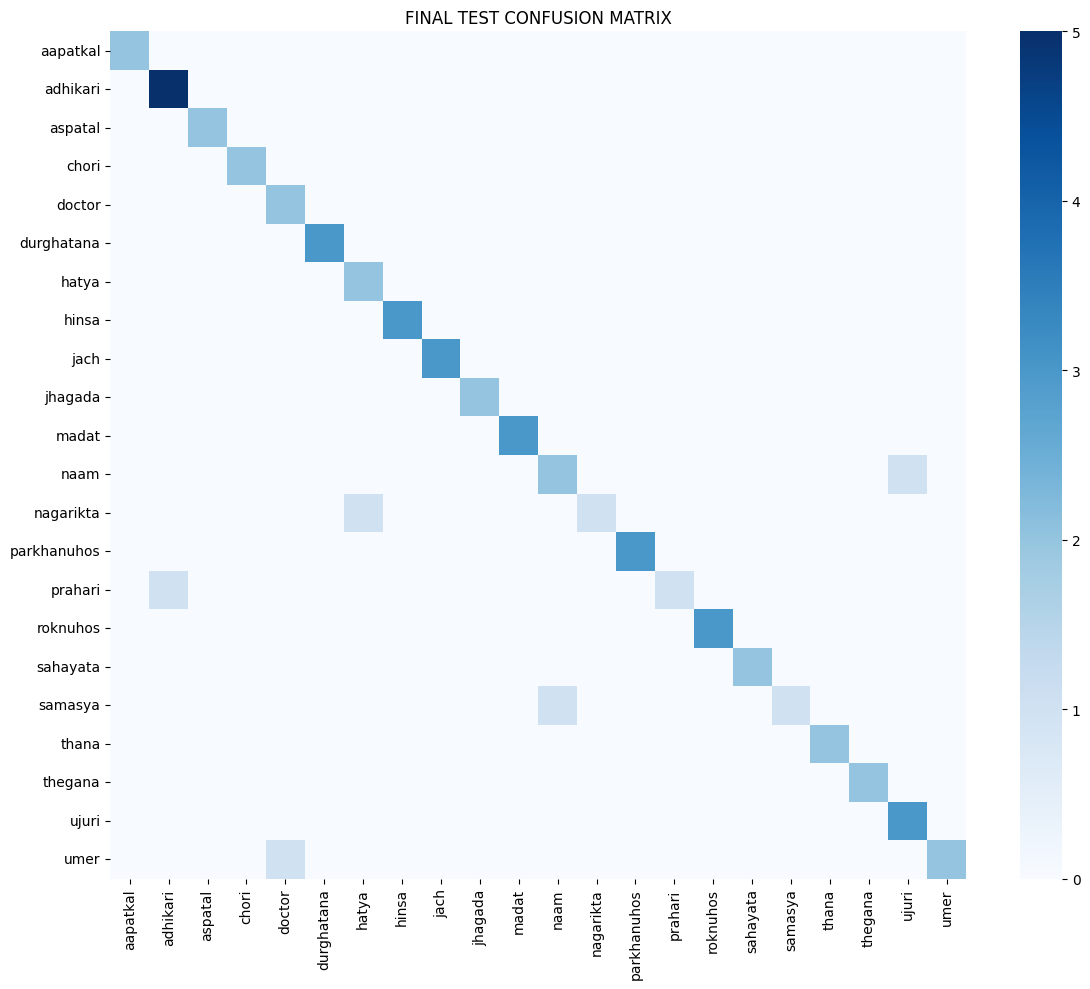

In [27]:

# =========================================================
# FINAL TEST CONFUSION MATRIX
# =========================================================

cm_test = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_test,
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("FINAL TEST CONFUSION MATRIX")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "final_test_cm.png"
    )
)

plt.show()

plt.close()

In [25]:

# =========================================================
# SAVE FINAL MODEL
# =========================================================

final_model.save(
    os.path.join(
        MODEL_DIR,
        "best_model.h5"
    )
)

meta = {

    "best_model": best_model_name,

    "validation_accuracy":
        float(results[best_model_name]),

    "test_accuracy":
        float(test_acc),

    "classes":
        list(le.classes_),

    "input_shape":
        input_shape
}

with open(
    os.path.join(
        MODEL_DIR,
        "meta.json"
    ),
    "w"
) as f:

    json.dump(meta, f, indent=2)

print("\n✅ TRAINING COMPLETE")


✅ TRAINING COMPLETE


In [ ]:

# =========================================================
# EVALUATE EACH MODEL ON TEST SET
# =========================================================

print("\n" + "="*70)
print("EVALUATING ALL MODELS ON TEST SET")
print("="*70)

all_models_results = {}

for model_name in results.keys():
    
    model_path = os.path.join(
        MODEL_DIR,
        f"{model_name}_best.h5"
    )
    
    if not os.path.exists(model_path):
        print(f"⚠️  Model file not found: {model_path}")
        continue
    
    print(f"\n{'─'*70}")
    print(f"Testing: {model_name}")
    print(f"{'─'*70}")
    
    # Load trained model
    model = tf.keras.models.load_model(
        model_path,
        compile=False
    )
    
    # Get predictions on test set
    test_pred = np.argmax(
        model.predict(X_test, verbose=0),
        axis=1
    )
    
    test_acc = accuracy_score(y_test, test_pred)
    all_models_results[model_name] = test_acc
    
    print(f"Test Accuracy: {test_acc:.4f}")
    
    # Classification report
    report = classification_report(
        y_test,
        test_pred,
        target_names=le.classes_
    )
    
    print(report)
    
    # Save classification report
    report_path = os.path.join(
        OUTPUT_DIR,
        f"{model_name}_test_report.txt"
    )
    
    with open(report_path, "w") as f:
        f.write(report)
    
    print(f"✓ Saved: {report_path}")
    
    # Save confusion matrix
    cm = confusion_matrix(y_test, test_pred)
    
    plt.figure(figsize=(12, 10))
    
    sns.heatmap(
        cm,
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        annot=True,
        fmt="d"
    )
    
    plt.title(
        f"Test Confusion Matrix - {model_name} (Acc: {test_acc:.4f})"
    )
    
    plt.tight_layout()
    
    cm_path = os.path.join(
        OUTPUT_DIR,
        f"{model_name}_test_cm.png"
    )
    
    plt.savefig(cm_path, dpi=150)
    plt.close()
    
    print(f"✓ Saved: {cm_path}")

print(f"\n{'='*70}")
print("TEST RESULTS SUMMARY:")
print(f"{'='*70}")

for model_name, acc in sorted(all_models_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name}: {acc:.4f}")

